In [1]:
import random

In [2]:
import numpy as np
import pandas as pd
from pycaret.regression import get_config
from pycaret.regression import set_config
from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    tune_model,
    ensemble_model,
    models,
    blend_models,
    stack_models,
    plot_model,
    evaluate_model,
    interpret_model,
    automl,
    predict_model,
    save_model,
    load_model,
    convert_model,
    create_api,
    create_docker
)
from pycaret.utils import version
from yellowbrick.regressor import CooksDistance

In [3]:
id_cols = ['productID',"name","pProductID", "wine_url","pageName","uploadDate"]
target_cols = ['WS']
categorical_cols=[
    "description", "productPrice", "productCompetitiveIntensity", "ProductAvailability", "priceCurrency", 	"additionalType" ,"productOrigin", "productVarietal", "productRegion"
]
extra_cols=["shippingRegion", "shipToState"]
other_ratings = [ 'JS', 'WW', 'D', 'BH', 'W&S', 'WE', 'RP', 'JD', 'SJ', 'V', 'CG', 'TP' ]
predictors = [
    'productStock',
    'price',
    'prodAlcoholPercent_percent'
    #'averageRating_bestRating',
    #'averageRating_worstRating',
    #'bestRating',
    #'worstRating',
    #'prodAlcoholVolume_text',
]

In [4]:
print(f"pycaret version = {version()}")
print("1. Loading Dataset")
df = pd.read_csv("wine_spectator.csv")
df = df.drop_duplicates('wine_url') 

pycaret version = 3.0.3
1. Loading Dataset


In [5]:

unnamed_cols=df.filter(regex="Unnamed")
df = df.drop(categorical_cols, axis=1)
df = df.drop(extra_cols, axis=1)
df = df.drop(unnamed_cols, axis=1)
df = df.drop(other_ratings, axis=1)

df = df[id_cols+predictors+target_cols]
indices = list(df.index)
n_samples = len(indices)
train_samples = int(0.8 * n_samples)
test_samples = n_samples - train_samples
print(f"train_samples = {train_samples}")
print(f"test_samples = {test_samples}")
random.shuffle(indices)
pick_k_random_indices = random.sample(indices, train_samples)
not_picked_indices = set(indices).difference(pick_k_random_indices)
df_train = df.loc[pick_k_random_indices, :]
df_train = df_train.dropna(subset=target_cols, axis=0)
df_train_id = df_train[id_cols]
df_train = df_train.drop(id_cols, axis=1)

train_samples = 1680
test_samples = 420


In [6]:
df_test = df.loc[not_picked_indices, :]
df_test_id = df_test[id_cols]
df_test_truth = df_test[target_cols]
df_test = df_test.drop(id_cols, axis=1)
df_test = df_test.drop(target_cols, axis=1)

In [7]:
print(list(df.describe()))

['productID', 'productStock', 'price', 'prodAlcoholPercent_percent', 'WS']


CooksDistance(ax=<Axes: >)

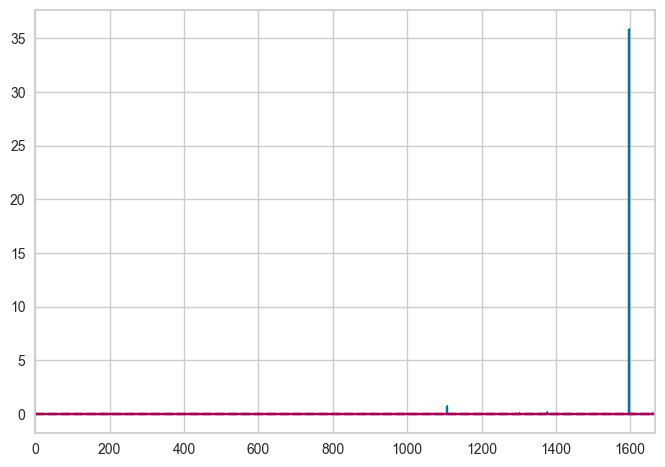

In [8]:
visualizer = CooksDistance()
visualizer.fit(df_train[predictors], df_train["WS"])
#visualizer.show()

In [9]:
df_train['cooks'] = visualizer.distance_
high_influence = df_train['cooks']>1.0
high_price = df_train['price']>500

In [42]:
df_train = df_train[~high_influence & ~high_price]
df_train = df_train.drop('cooks',axis=1)

In [11]:
df_train_id = df_train_id[~high_influence & ~high_price]

In [12]:
print("2. Initialize Setup")
reg1 = setup(
    data=df_train,
    target="WS",
    experiment_name='ws_from_meta',
    imputation_type='iterative',    
)

2. Initialize Setup


,Description,Value
0,Session id,2345
1,Target,WS
2,Target type,Regression
3,Original data shape,"(1592, 5)"
4,Transformed data shape,"(1592, 5)"
5,Transformed train set shape,"(1114, 5)"
6,Transformed test set shape,"(478, 5)"
7,Numeric features,4
8,Preprocess,True
9,Imputation type,iterative


In [13]:
print("3. Compare Baseline")

best_model = compare_models(fold=5)

3. Compare Baseline


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4860,0.8568,0.9226,0.7442,0.0099,0.0053,0.2820
rf,Random Forest Regressor,0.4737,0.8974,0.9394,0.7326,0.0101,0.0051,0.2940
lightgbm,Light Gradient Boosting Machine,0.5704,0.9628,0.9787,0.7124,0.0105,0.0062,0.0980
gbr,Gradient Boosting Regressor,0.6921,1.1262,1.0574,0.6647,0.0113,0.0075,0.2080
dt,Decision Tree Regressor,0.4479,1.5826,1.2442,0.5314,0.0133,0.0049,0.0620
ada,AdaBoost Regressor,1.0218,1.6321,1.2757,0.5144,0.0137,0.0111,0.0940
lasso,Lasso Regression,1.2096,2.2624,1.5017,0.3301,0.0160,0.0131,0.0720
en,Elastic Net,1.2096,2.2623,1.5016,0.3301,0.0160,0.0131,0.0700
omp,Orthogonal Matching Pursuit,1.2110,2.2610,1.5013,0.3301,0.0160,0.0131,0.0700
ridge,Ridge Regression,1.2095,2.2620,1.5016,0.3300,0.0160,0.0131,0.0660


In [14]:
print("4. Create Model")
lr = create_model('lr')
lr = tune_model(lr, n_iter=5, optimize='RMSE')
evaluate_model(lr)

4. Create Model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.0536,1.7200,1.3115,0.3525,0.0140,0.0114
1,1.1079,1.9946,1.4123,0.1918,0.0151,0.0120
2,1.4373,6.5963,2.5683,-0.3685,0.0257,0.0155
3,1.3223,2.5446,1.5952,0.2692,0.0170,0.0142
4,1.2475,2.4500,1.5652,0.3430,0.0167,0.0135
5,1.2236,2.1228,1.4570,0.3498,0.0156,0.0132
6,1.2234,2.2495,1.4998,0.3492,0.0161,0.0133
7,1.2064,2.1383,1.4623,0.2498,0.0156,0.0131
8,1.1263,2.0145,1.4193,0.3919,0.0152,0.0122


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.0536,1.7200,1.3115,0.3525,0.0140,0.0114
1,1.1079,1.9946,1.4123,0.1918,0.0151,0.0120
2,1.4373,6.5963,2.5683,-0.3685,0.0257,0.0155
3,1.3223,2.5446,1.5952,0.2692,0.0170,0.0142
4,1.2475,2.4500,1.5652,0.3430,0.0167,0.0135
5,1.2236,2.1228,1.4570,0.3498,0.0156,0.0132
6,1.2234,2.2495,1.4998,0.3492,0.0161,0.0133
7,1.2064,2.1383,1.4623,0.2498,0.0156,0.0131
8,1.1263,2.0145,1.4193,0.3919,0.0152,0.0122


Fitting 10 folds for each of 2 candidates, totalling 20 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [15]:
rf = create_model('rf')
rf = tune_model(rf, n_iter=5, optimize='RMSE')
evaluate_model(rf)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3671,0.4962,0.7044,0.8132,0.0075,0.0040
1,0.4334,0.6903,0.8309,0.7203,0.0089,0.0047
2,0.3960,0.6827,0.8263,0.8584,0.0089,0.0043
3,0.5257,0.8973,0.9473,0.7423,0.0101,0.0056
4,0.5578,1.3264,1.1517,0.6443,0.0123,0.0061
5,0.4634,0.8084,0.8991,0.7524,0.0096,0.0050
6,0.5460,1.1493,1.0721,0.6675,0.0116,0.0060
7,0.4513,0.9528,0.9761,0.6657,0.0105,0.0049
8,0.3509,0.4667,0.6832,0.8591,0.0073,0.0038


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6004,0.7781,0.8821,0.7071,0.0094,0.0065
1,0.6586,0.9068,0.9522,0.6326,0.0102,0.0072
2,0.5837,0.7580,0.8706,0.8427,0.0093,0.0063
3,0.7630,1.2282,1.1082,0.6473,0.0118,0.0082
4,0.7802,1.4584,1.2076,0.6089,0.0130,0.0085
5,0.7047,1.0522,1.0258,0.6777,0.0110,0.0076
6,0.7220,1.1387,1.0671,0.6706,0.0115,0.0079
7,0.7148,1.2186,1.1039,0.5725,0.0118,0.0078
8,0.5803,0.7025,0.8381,0.7880,0.0090,0.0063


Fitting 10 folds for each of 5 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [16]:
knn=create_model('knn')
knn = tune_model(knn, n_iter=5, optimize='RMSE')
evaluate_model(knn)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.1536,1.9793,1.4069,0.2548,0.0151,0.0125
1,1.1643,2.2529,1.5010,0.0872,0.0161,0.0126
2,1.2054,2.2489,1.4996,0.5334,0.0159,0.0129
3,1.2679,2.4450,1.5636,0.2978,0.0167,0.0137
4,1.2685,2.5031,1.5821,0.3287,0.0169,0.0137
5,1.3081,2.5658,1.6018,0.2142,0.0171,0.0141
6,1.1387,2.0454,1.4302,0.4083,0.0153,0.0124
7,1.1586,2.1719,1.4737,0.2380,0.0157,0.0126
8,1.0883,1.9344,1.3908,0.4161,0.0149,0.0118


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.0851,1.8144,1.3470,0.3169,0.0144,0.0118
1,1.0700,1.8477,1.3593,0.2513,0.0146,0.0116
2,1.2401,2.4079,1.5517,0.5004,0.0164,0.0133
3,1.2467,2.2854,1.5118,0.3437,0.0161,0.0134
4,1.2233,2.3665,1.5383,0.3654,0.0164,0.0132
5,1.1617,1.9169,1.3845,0.4129,0.0148,0.0125
6,1.1147,1.8926,1.3757,0.4525,0.0148,0.0121
7,1.1650,2.0495,1.4316,0.2810,0.0153,0.0126
8,1.0171,1.6822,1.2970,0.4923,0.0139,0.0110


Fitting 10 folds for each of 5 candidates, totalling 50 fits


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [17]:
print("5. Tune Hyperparameters")
lightgbm = create_model('lightgbm')
lightgbm = tune_model(lightgbm, n_iter=5, optimize='MAE')
evaluate_model(lightgbm)

5. Tune Hyperparameters


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4651,0.6542,0.8088,0.7537,0.0087,0.0050
1,0.5191,0.9137,0.9559,0.6298,0.0102,0.0056
2,0.4635,0.6835,0.8268,0.8582,0.0089,0.0050
3,0.5975,0.8244,0.9080,0.7632,0.0097,0.0064
4,0.6474,1.5150,1.2309,0.5937,0.0132,0.0070
5,0.5215,0.7600,0.8718,0.7673,0.0093,0.0056
6,0.6251,1.1900,1.0909,0.6557,0.0118,0.0068
7,0.5836,1.1802,1.0864,0.5860,0.0117,0.0064
8,0.4405,0.5729,0.7569,0.8271,0.0081,0.0048


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6254,0.7690,0.8769,0.7105,0.0094,0.0068
1,0.6739,0.9772,0.9885,0.6041,0.0106,0.0073
2,0.7029,1.0866,1.0424,0.7746,0.0111,0.0076
3,0.8185,1.3896,1.1788,0.6009,0.0126,0.0088
4,0.8671,1.6954,1.3021,0.5454,0.0140,0.0094
5,0.7719,1.1270,1.0616,0.6548,0.0113,0.0083
6,0.7688,1.1865,1.0893,0.6568,0.0117,0.0084
7,0.7025,1.0731,1.0359,0.6235,0.0111,0.0077
8,0.6791,1.0090,1.0045,0.6954,0.0108,0.0074


Fitting 10 folds for each of 5 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [18]:
print("6. Ensemble Model")

6. Ensemble Model


In [19]:
dt = create_model('dt')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2589,0.6875,0.8292,0.7412,0.0088,0.0028
1,0.5000,1.4464,1.2027,0.4139,0.0129,0.0055
2,0.3125,0.8839,0.9402,0.8166,0.0101,0.0034
3,0.4286,1.3750,1.1726,0.6051,0.0125,0.0046
4,0.5405,2.0901,1.4457,0.4395,0.0155,0.0059
5,0.3694,1.3243,1.1508,0.5944,0.0123,0.0040
6,0.4505,1.5495,1.2448,0.5517,0.0133,0.0049
7,0.4054,1.4865,1.2192,0.4785,0.0131,0.0044
8,0.3604,0.9910,0.9955,0.7009,0.0107,0.0039


In [20]:
bagged_dt = ensemble_model(dt, n_estimators=50)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3611,0.4771,0.6907,0.8204,0.0074,0.0039
1,0.4216,0.6752,0.8217,0.7264,0.0088,0.0046
2,0.4021,0.7613,0.8725,0.8421,0.0094,0.0043
3,0.5307,0.8750,0.9354,0.7487,0.0100,0.0057
4,0.5447,1.3372,1.1564,0.6414,0.0124,0.0059
5,0.4686,0.8344,0.9135,0.7444,0.0098,0.0050
6,0.5445,1.1334,1.0646,0.6721,0.0115,0.0059
7,0.4674,0.9958,0.9979,0.6506,0.0107,0.0051
8,0.3641,0.4879,0.6985,0.8527,0.0075,0.0040


In [21]:
boosted_dt = ensemble_model(dt, method='Boosting')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2768,0.7232,0.8504,0.7277,0.0091,0.0030
1,0.2768,0.7589,0.8712,0.6925,0.0093,0.0030
2,0.1786,0.3393,0.5825,0.9296,0.0063,0.0019
3,0.3839,1.0268,1.0133,0.7051,0.0108,0.0041
4,0.4955,1.7748,1.3322,0.5241,0.0143,0.0054
5,0.3063,1.0450,1.0223,0.6799,0.0109,0.0033
6,0.3694,1.1622,1.0780,0.6638,0.0116,0.0041
7,0.3514,1.3243,1.1508,0.5354,0.0123,0.0039
8,0.2252,0.6757,0.8220,0.7961,0.0088,0.0024


In [22]:
print("7. Blend Models")

7. Blend Models


In [23]:
list(models().index)

['lr',
 'lasso',
 'ridge',
 'en',
 'lar',
 'llar',
 'omp',
 'br',
 'ard',
 'par',
 'ransac',
 'tr',
 'huber',
 'kr',
 'svm',
 'knn',
 'dt',
 'rf',
 'et',
 'ada',
 'gbr',
 'mlp',
 'lightgbm',
 'dummy']

In [24]:
top_five = compare_models(n_select=5, fold=5, include=list(models().index))

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4860,0.8568,0.9226,0.7442,0.0099,0.0053,0.1100
rf,Random Forest Regressor,0.4737,0.8974,0.9394,0.7326,0.0101,0.0051,0.1200
lightgbm,Light Gradient Boosting Machine,0.5704,0.9628,0.9787,0.7124,0.0105,0.0062,0.0920
gbr,Gradient Boosting Regressor,0.6921,1.1262,1.0574,0.6647,0.0113,0.0075,0.1100
dt,Decision Tree Regressor,0.4479,1.5826,1.2442,0.5314,0.0133,0.0049,0.0680
ada,AdaBoost Regressor,1.0218,1.6321,1.2757,0.5144,0.0137,0.0111,0.0840
svm,Support Vector Regression,1.1784,2.1743,1.4716,0.3575,0.0157,0.0127,0.0840
en,Elastic Net,1.2096,2.2623,1.5016,0.3301,0.0160,0.0131,0.0660
omp,Orthogonal Matching Pursuit,1.2110,2.2610,1.5013,0.3301,0.0160,0.0131,0.0660
ard,Automatic Relevance Determination,1.2110,2.2610,1.5013,0.3301,0.0160,0.0131,0.0760


In [25]:
blender = blend_models(estimator_list=top_five)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3919,0.4734,0.6880,0.8218,0.0074,0.0042
1,0.4749,0.7692,0.8770,0.6883,0.0094,0.0052
2,0.4085,0.6168,0.7853,0.8720,0.0084,0.0044
3,0.5635,0.9149,0.9565,0.7373,0.0102,0.0061
4,0.6016,1.3367,1.1562,0.6415,0.0124,0.0065
5,0.4641,0.7053,0.8398,0.7840,0.0090,0.0050
6,0.5476,0.9688,0.9843,0.7197,0.0106,0.0060
7,0.5252,1.0542,1.0267,0.6302,0.0110,0.0057
8,0.3925,0.4706,0.6860,0.8579,0.0074,0.0043


In [26]:
print("8. Stack Models")

8. Stack Models


In [27]:
stacker = stack_models(estimator_list=top_five)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3643,0.4370,0.6611,0.8355,0.0071,0.0039
1,0.4150,0.7376,0.8589,0.7011,0.0092,0.0045
2,0.3812,0.5929,0.7700,0.8770,0.0083,0.0041
3,0.5681,0.9325,0.9657,0.7322,0.0103,0.0061
4,0.5570,1.3558,1.1644,0.6364,0.0125,0.0060
5,0.4163,0.6372,0.7982,0.8049,0.0085,0.0045
6,0.5238,0.9334,0.9661,0.7300,0.0104,0.0057
7,0.4895,1.0475,1.0235,0.6325,0.0110,0.0054
8,0.3582,0.4650,0.6819,0.8596,0.0073,0.0039


In [28]:
print("9. Analyze Model")

9. Analyze Model


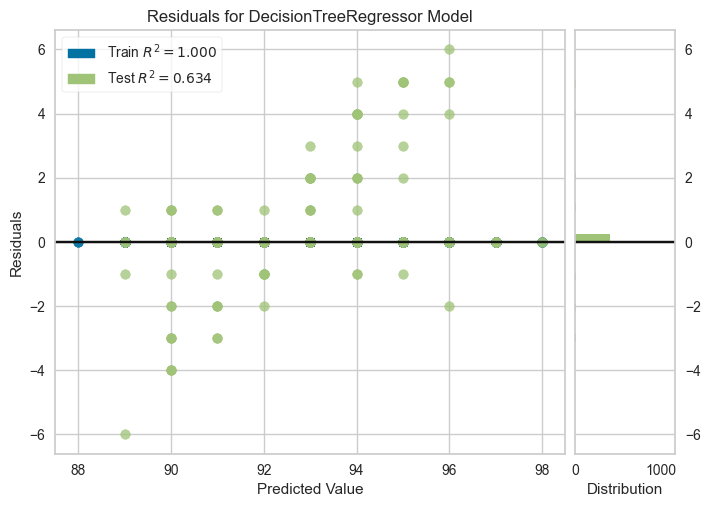

In [29]:
plot_model(dt)

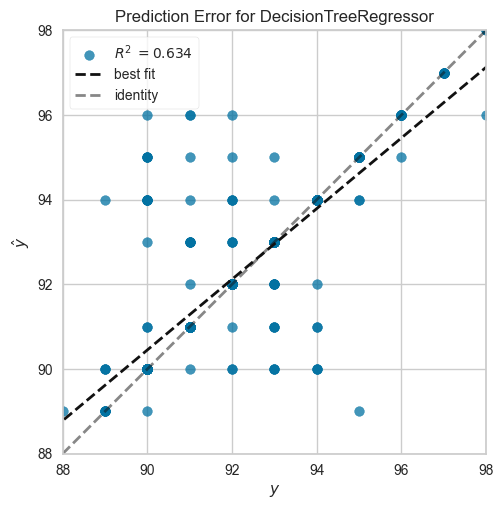

In [30]:
plot_model(dt, plot='error')

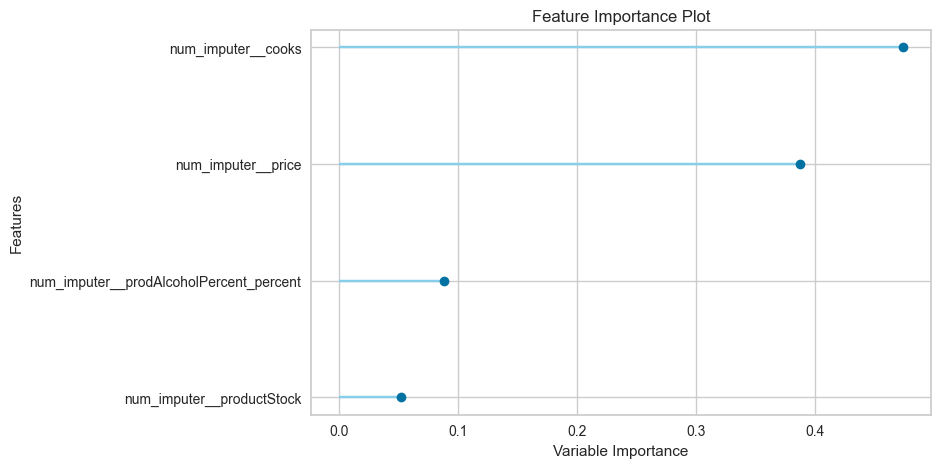

In [31]:
plot_model(dt, plot='feature')

In [32]:
evaluate_model(dt)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [33]:
print("10. Interpret Model")

10. Interpret Model


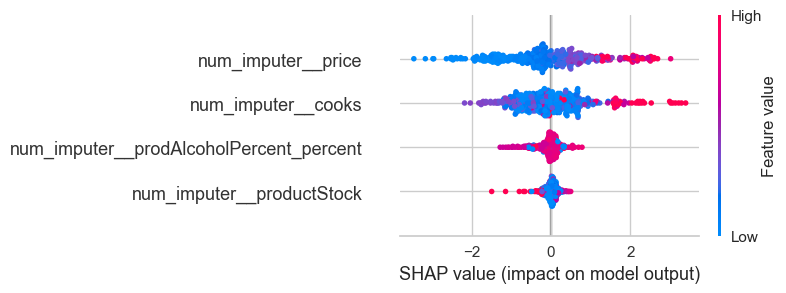

In [34]:
interpret_model(lightgbm)

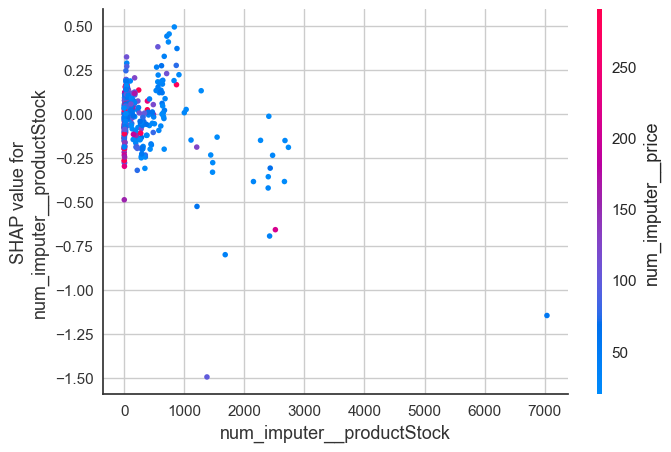

In [35]:
interpret_model(lightgbm, plot='correlation')

In [36]:
interpret_model(lightgbm, plot='reason', observation=12)

In [37]:
print("11. AutoML()")

11. AutoML()


In [38]:
best = automl(optimize='MAE')
print(best)

AdaBoostRegressor(base_estimator=DecisionTreeRegressor(random_state=2345),
                  n_estimators=10, random_state=2345)


In [39]:
print("12. Predict Model")

12. Predict Model


In [40]:
pred_holdouts = predict_model(lightgbm)
pred_holdouts.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.4891,0.8211,0.9062,0.7529,0.0097,0.0053


,productStock,price,prodAlcoholPercent_percent,cooks,WS,prediction_label
655,19.0,84.989998,13.5,0.000005,92.0,91.924113
1589,749.0,23.990000,13.6,0.000383,90.0,90.659922
995,26.0,25.990000,10.0,0.000185,90.0,90.368200
573,1.0,359.970001,0.0,0.000517,91.0,94.490706
723,265.0,67.989998,20.0,0.000002,92.0,92.311212


In [41]:
predict_new = predict_model(best, data=df_test)
predict_new.head()

KeyError: "['cooks'] not in index"

In [ ]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(predict_new['prediction_label'],df_test_truth)
ax.set_xlabel('predicted WS rating')
ax.set_ylabel('actual WS rating')

In [ ]:
save_model(best, model_name='best-model')

In [ ]:
convert_model()

In [ ]:
loaded_bestmodel = load_model('best-model')
print(loaded_bestmodel)

In [ ]:
print(loaded_bestmodel[0])

In [ ]:
X_train = get_config('X_train')
X_train.head()

In [ ]:
convert_model(best_model,'c')

In [ ]:
create_api(best_model,api_name='predict_ws_from_meta')

In [ ]:
create_docker(api_name='predict_ws_from_meta')